In [ ]:
from json import load
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
## load the data
def load_hw1_problem1_data(data_path):
    data_path = Path(data_path)
    df = pd.read_csv(data_path)
    x = df["X"].to_numpy(dtype=float)
    y = df["Y"].to_numpy(dtype=float)
    return x, y, df

def generate_hw1_problem1_synth(
    n=200,
    theta1_true=1.5,
    theta2_true=2.0,
    noise_std=0.2,
    seed=123,
):
    np.random.seed(seed)
    x = np.random.uniform(0, 10, n)
    y_true = model_fn(x, theta1_true, theta2_true)
    noise = np.random.normal(0, noise_std, n)
    y = y_true + noise
    
    return x, y
    
    pass
## process function
def model_fn(x, theta1, theta2):
    out = theta1*(np.sin(x) + np.cos(theta2 * x))
    return out

## loss function
def square_error_loss(y_true, y_pred):
    return sum((y_pred - y_true)**2)



In [ ]:
## load in the data
x, y, df = load_hw1_problem1_data('../src/dataset/homework/HW1_Problem1_Data.csv')

## Problem 1

In [ ]:
## Problem 1.a
plt.scatter(x, y, color='blue', label='Data Points')
plt.xlabel('X'); plt.ylabel('Y')
plt.title('Scatter Plot of Data Points')
plt.legend()


In [ ]:
## Problem 1.b
def SGD(x, y, init = {"theta1": 1, "theta2": 1}, epsilon = 0.01, batch_size = 32, max_iter = 1000):
    
    theta1 = init.get("theta1")
    theta2 = init.get("theta2")

    loss = square_error_loss(y, model_fn(x, theta1, theta2))

    n_sample = len(x)
    iters = 0
    loss_history = []
    while loss > 1e-02 and iters < max_iter:
        m = batch_size
        indices = np.random.choice(n_sample, size=m, replace=False)
        x_batch = x[indices]
        y_batch = y[indices]

        y_pred = model_fn(x_batch, theta1, theta2)
        error = y_batch - y_pred
        
        dtheta1 = np.sin(x_batch)  + np.cos(theta2 * x_batch)
        g1 = (-2 / m) * np.sum(error * dtheta1)
        
        dtheta2 = theta1 * x_batch * np.sin(theta2 * x_batch)
        g2 = ( 2 / m) * np.sum(error * dtheta2)
        theta1 = theta1 - epsilon * g1
        theta2 = theta2 - epsilon * g2
        loss = square_error_loss(y, model_fn(x, theta1, theta2))
        iters += 1
        # print(f"Iteration {iters}: Loss = {loss:.4f}, theta1 = {theta1:.4f}, theta2 = {theta2:.4f}")
        loss_history.append(loss)  
    theta = {"theta1": theta1, "theta2": theta2}
    print(f"SGD finished  in {iters} iterations with loss: {loss:.4f}")
    return loss, theta, loss_history

In [ ]:
## Problem 1.c
def SGD_momentum(x, y, init = {"theta1": 1, "theta2": 1}, alpha = .9, epsilon = 0.01, batch_size = 32, max_iter = 1000):
    
    theta1 = init.get("theta1")
    theta2 = init.get("theta2")

    loss = square_error_loss(y, model_fn(x, theta1, theta2))

    n_sample = len(x)
    iters = 0
    loss_history = []
    v1, v2 = 0, 0
    while loss > 1e-02 and iters < max_iter:
        m = batch_size
        indices = np.random.choice(n_sample, size=m, replace=False)
        x_batch = x[indices]
        y_batch = y[indices]

        y_pred = model_fn(x_batch, theta1, theta2)
        error = y_batch - y_pred
        
        dtheta1 = np.sin(x_batch)  + np.cos(theta2 * x_batch)
        g1 = (-2 / m) * np.sum(error * dtheta1)

        dtheta2 = theta1 * x_batch * np.sin(theta2 * x_batch)
        g2 = ( 2 / m) * np.sum(error * dtheta2)

        v1 = alpha * v1 - epsilon * g1
        v2 = alpha * v2 - epsilon * g2

        theta1 = theta1 + v1
        theta2 = theta2 + v2
        loss = square_error_loss(y, model_fn(x, theta1, theta2))
        iters += 1
        # print(f"Iteration {iters}: Loss = {loss:.4f}, theta1 = {theta1:.4f}, theta2 = {theta2:.4f}")
        ## save every loss_historys
        loss_history.append(loss)
    theta = {"theta1": theta1, "theta2": theta2}
    print(f"SGD momentum finished in {iters} iterations with loss: {loss:.4f}")
    return loss, theta, loss_history

SGD finished  in 100 iterations with loss: 8.3365
SGD momentum finished in 100 iterations with loss: 8.0645
None


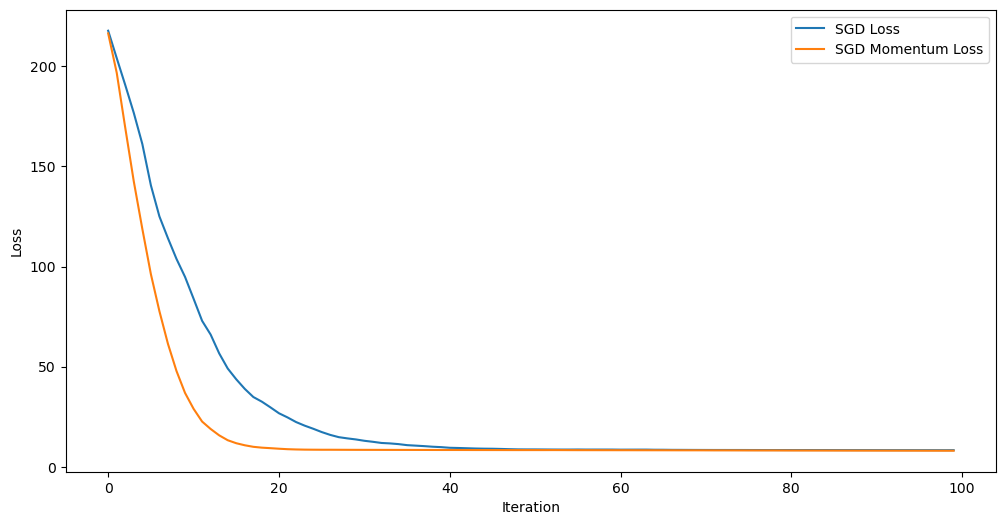

In [10]:
## test data for both
def test():
    test_x, test_y = generate_hw1_problem1_synth(n=200, theta1_true=1.5, theta2_true=2.0, noise_std=0.2, seed=123)
    loss_sgd, theta_sgd, loss_history_sgd = SGD(test_x, test_y, init = {"theta1": 1.4, "theta2": 1.8}, epsilon = 0.001, batch_size = 32, max_iter=100)
    loss_momentum, theta_momentum, loss_history_momentum = SGD_momentum(test_x, test_y, init = {"theta1": 1.4, "theta2": 1.8}, alpha = 0.5, epsilon = 0.001, batch_size = 32, max_iter = 100)
    plt.figure(figsize=(12, 6))
    plt.plot(loss_history_sgd, label='SGD Loss')
    plt.plot(loss_history_momentum, label='SGD Momentum Loss')
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.legend()
print(test())

In [12]:
## Problem 1.d
def Adam(x, y, init = {"theta1": 1, "theta2": 1}, epsilon = 0.001, rho1 = 0.9, rho2 = 0.999, batch_size = 32, max_iter = 1000):
    
    theta1 = init.get("theta1")
    theta2 = init.get("theta2")

    ## delta for numerical stability
    delta  = 1e-8

    ## initial 1st and 2nd moment variables
    s1 = 0
    s2 = 0
    r1 = 0
    r2 = 0

    ## exponential decay rates
    rho1 = rho1
    rho2 = rho2

    ## time step
    t = 0

    ## initial loss
    loss = square_error_loss(y, model_fn(x, theta1, theta2))

    n_sample = len(x)
    iters = 0
    loss_history = []

    while loss > 1e-02 and iters < max_iter:
        m = batch_size
        indices = np.random.choice(n_sample, size=m, replace=False)
        x_batch = x[indices]
        y_batch = y[indices]

        y_pred = model_fn(x_batch, theta1, theta2)
        error = y_batch - y_pred

        t += 1
        bias_correction_s = 1 - rho1**t
        bias_correction_r = 1 - rho2**t
        
        ## update the gradiant for every step 
        dtheta1 = np.sin(x_batch)  + np.cos(theta2 * x_batch)
        dtheta2 = theta1 * x_batch * np.sin(theta2 * x_batch)
        
        ## update theta 1
        g1 = (-2 / m) * np.sum(error * dtheta1)

        ## update biased first moment estimate
        s1 = rho1 * s1 + (1 - rho1) * g1
        ## update biased second moment estimate
        r1 = rho2 * r1 + (1 - rho2) * g1 * g1

        ## correct bias for the moment
        s1hat = s1 / bias_correction_s
        r1hat = r1 / bias_correction_r

        theta1 = theta1 - epsilon * s1hat / np.sqrt(r1hat + delta)
        
        ## update theta 2
        g2 = ( 2 / m) * np.sum(error * dtheta2)

        ## update biased first moment estimate
        s2 = rho1 * s2 + (1 - rho1) * g2
        ## update biased second moment estimate
        r2 = rho2 * r2 + (1 - rho2) * g2 * g2

        ## correct bias for the moment
        s2hat = s2 / bias_correction_s
        r2hat = r2 / bias_correction_r

        theta2 = theta2 - epsilon * s2hat / np.sqrt(r2hat + delta)
        loss = square_error_loss(y, model_fn(x, theta1, theta2))
        iters += 1
        # print(f"Iteration {iters}: Loss = {loss:.4f}, theta1 = {theta1:.4f}, theta2 = {theta2:.4f}")
        loss_history.append(loss)  
    theta = {"theta1": theta1, "theta2": theta2}
    print(f"Adam finished  in {iters} iterations with loss: {loss:.4f}")
    return loss, theta, loss_history
    

SGD finished  in 1000 iterations with loss: 7.3672
SGD momentum finished in 1000 iterations with loss: 7.3163
Adam finished  in 1000 iterations with loss: 7.3107


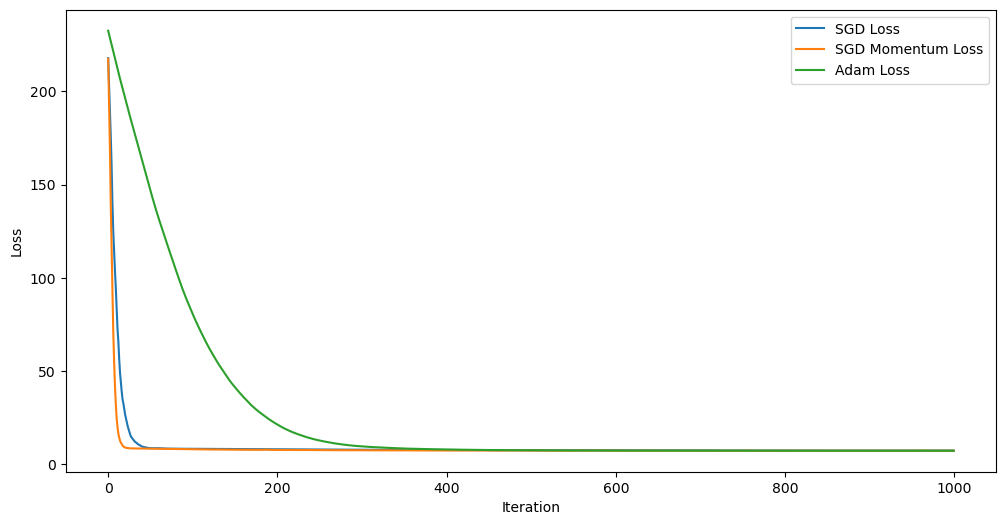

In [13]:
def test():
    test_x, test_y = generate_hw1_problem1_synth(n=200, theta1_true=1.5, theta2_true=2.0, noise_std=0.2, seed=123)
    loss_sgd, theta_sgd, loss_history_sgd = SGD(test_x, test_y, init = {"theta1": 1.4, "theta2": 1.8}, epsilon = 0.001, batch_size = 32, max_iter=1000)
    loss_momentum, theta_momentum, loss_history_momentum = SGD_momentum(test_x, test_y, init = {"theta1": 1.4, "theta2": 1.8}, alpha = 0.5, epsilon = 0.001, batch_size = 32, max_iter = 1000)
    loss_adam, theta_adam, loss_history_adam = Adam(test_x, test_y, init = {"theta1": 1.4, "theta2": 1.8}, epsilon = 0.001, rho1 = 0.9, rho2 = 0.999, batch_size = 32, max_iter = 1000)
    plt.figure(figsize=(12, 6))
    plt.plot(loss_history_sgd, label='SGD Loss')
    plt.plot(loss_history_momentum, label='SGD Momentum Loss')
    plt.plot(loss_history_adam, label='Adam Loss')
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.legend()
test()

In [ ]:
## Problem 1.f PSO
def near_neighbor(i, p_all, Q_all, K):
    diff = p_all[i] - p_all
    distance = np.sqrt(np.sum(diff ** 2, axis = 1))

    K = min(K, len(p_all) - 1)

    K_idx = np.argpartition(distance, K)[:K]
    best_idx = K_idx[np.argmin(Q_all[K_idx])]
    return p_all[best_idx]

    
def PSO(x, y, w, c1, c2, n, K, max_iter = 1000):
    niters = 0
    theta = np.array([[np.random.uniform(0, 1), np.random.uniform(3, 5)] for _ in range(n)])
    p = theta.copy()
    v = np.zeros((n,2))
    loss_history = []
    ## get loss of all
    def get_all_loss(current_p):
        return np.array([square_error_loss(y, model_fn(x, row[0], row[1])) for row in current_p])
    
    Q_all = get_all_loss(p)
    while niters < max_iter:
        for i in range(n):
            # y_theta = model_fn(x, theta[0], theta[1])
            # y_p = model_fn(x, p[0], p[1])
            current_loss = square_error_loss(y, model_fn(x, theta[i, 0], theta[i, 1]))
            if current_loss < Q_all[i]:
                p[i] = theta[i].copy()
                Q_all[i] = current_loss
            g_i = near_neighbor(i, p, Q_all, K)
            r1, r2 = np.random.uniform(0,1, size = 2)
            phi1 = c1 * r1
            phi2 = c2 * r2
            v[i]  = w * v[i] + phi1 * (p[i] - theta[i]) + phi2 * (g_i - theta[i])
            theta[i] = theta[i] + v[i]
        niters += 1
        loss = np.min(Q_all)
        loss_history = np.append(loss_history, loss)
        print(f"PSO finished  in {niters} iterations with loss: {loss:.4f}")
        
    return loss, p[np.argmin(Q_all)], loss_history

In [16]:
theta1_init = 1
theta2_init = 4
## summarise all results
loss_sgd, theta_sgd, loss_history_sgd = SGD(x, y, init = {"theta1": theta1_init, "theta2": 4}, epsilon = 0.0001, batch_size = 32, max_iter=20000)
loss_momentum, theta_momentum, loss_history_momentum = SGD_momentum(x, y, init = {"theta1": theta1_init, "theta2": 4}, alpha = 0.5, epsilon = 0.0001, batch_size = 32, max_iter = 20000)
loss_adam, theta_adam, loss_history_adam = Adam(x, y,init = {"theta1": theta1_init, "theta2": 4}, epsilon = 0.0001, rho1 = 0.9, rho2 = 0.999, batch_size = 32, max_iter = 20000)
loss_pso, theta_pso, loss_history_pso = PSO(x, y, w = 0.5, c1 = 1.0, c2 = 1.0, n = 50, K = 10, max_iter = 2000)

SGD finished  in 20000 iterations with loss: 48.9788
SGD momentum finished in 20000 iterations with loss: 48.9728
Adam finished  in 20000 iterations with loss: 48.9726
PSO finished  in 1 iterations with loss: 103.4097
PSO finished  in 2 iterations with loss: 49.8840
PSO finished  in 3 iterations with loss: 49.8256
PSO finished  in 4 iterations with loss: 49.8256
PSO finished  in 5 iterations with loss: 49.6760
PSO finished  in 6 iterations with loss: 49.5795
PSO finished  in 7 iterations with loss: 49.5795
PSO finished  in 8 iterations with loss: 49.5795
PSO finished  in 9 iterations with loss: 49.3804
PSO finished  in 10 iterations with loss: 49.0598
PSO finished  in 11 iterations with loss: 49.0293
PSO finished  in 12 iterations with loss: 49.0293
PSO finished  in 13 iterations with loss: 48.9970
PSO finished  in 14 iterations with loss: 48.9852
PSO finished  in 15 iterations with loss: 48.9852
PSO finished  in 16 iterations with loss: 48.9730
PSO finished  in 17 iterations with loss

In [26]:
results = [
    {
        "optimizer" : "SGD",
        "final loss": loss_sgd.item(),
        "final theta": theta_sgd.items(),
        "max interation": 20000,
        "key parameters": "epsilon = 0.0001, batch_size = 32"
    },
    {
        "optimizer" : "SGD Momentum",
        "final loss": loss_momentum.item(),
        "final theta": theta_momentum.items(),
        "max interation": 20000,
        "key parameters": "alpha = 0.5, epsilon = 0.0001, batch_size = 32"
    },
    {
        "optimizer" : "Adam",
        "final loss": loss_adam.item(),
        "final theta": theta_adam.items(),
        "max interation": 20000,
        "key parameters": "epsilon = 0.0001, rho1 = 0.9, rho2 = 0.999, batch_size = 32"
    },
    {
        "optimizer" : "PSO",
        "final loss": loss_pso.item(),
        "final theta": theta_pso,
        "max interation": 2000,
        "key parameters": "w = 0.5, c1 = 1.0, c2 = 1.0, n = 50, K = 10"
    }
]

print(results)

[{'optimizer': 'SGD', 'final loss': 48.978751478045425, 'final theta': dict_items([('theta1', np.float64(0.8653657398830262)), ('theta2', np.float64(3.9986987637567073))]), 'max interation': 20000, 'key parameters': 'epsilon = 0.0001, batch_size = 32'}, {'optimizer': 'SGD Momentum', 'final loss': 48.972750495458314, 'final theta': dict_items([('theta1', np.float64(0.8607777862208233)), ('theta2', np.float64(3.9978759029783975))]), 'max interation': 20000, 'key parameters': 'alpha = 0.5, epsilon = 0.0001, batch_size = 32'}, {'optimizer': 'Adam', 'final loss': 48.9726257324219, 'final theta': dict_items([('theta1', np.float64(0.8604371040239289)), ('theta2', np.float64(3.9979547372965114))]), 'max interation': 20000, 'key parameters': 'epsilon = 0.0001, rho1 = 0.9, rho2 = 0.999, batch_size = 32'}, {'optimizer': 'PSO', 'final loss': 48.97230778958634, 'final theta': array([0.86090758, 3.99820408]), 'max interation': 2000, 'key parameters': 'w = 0.5, c1 = 1.0, c2 = 1.0, n = 50, K = 10'}]
